87111


/var/folders/m0/hlc6y73128n1wbz2yg_t5bh40000gn/T/ipykernel_23796/3017806121.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_rate = df.groupby('xg_bin')['goal'].mean().fillna(0)


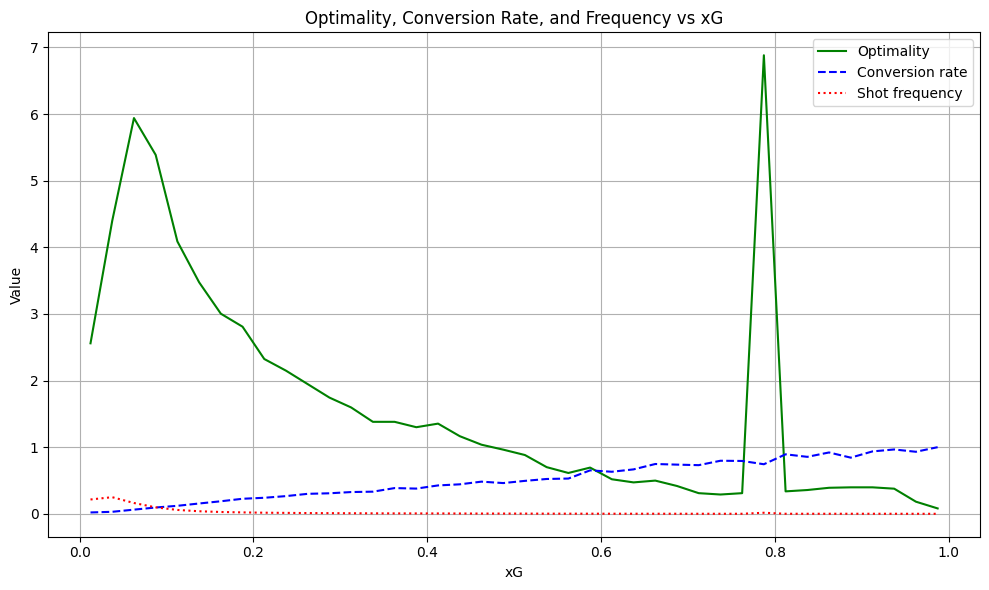

41
40


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/jackcolvin/downloads/shots_minimal.csv")

#using outcome to define an idea of conversion rate
df['goal'] = df['outcome'].apply(lambda x: 1 if x == "Goal" else 0)

print(len(df['outcome']))
#define xG bins
bin_width = 0.025
xg_bins = np.arange(0, 1+bin_width, bin_width)
bin_labels = xg_bins[:-1] + bin_width/2  

#bin each shot into xG bins
df['xg_bin'] = pd.cut(df['xg'], bins=xg_bins, labels=bin_labels, include_lowest=True)


conversion_rate = df.groupby('xg_bin')['goal'].mean().fillna(0)


shot_counts = df['xg_bin'].value_counts().sort_index()
frequency = shot_counts / len(df)

#compute optimality using our formula 
optimality = conversion_rate * frequency

#normalize optimality

optimality = optimality / np.median(optimality)
#plot
plt.figure(figsize=(10,6))
plt.plot(bin_labels, optimality, label='Optimality', color='green')
plt.plot(bin_labels, conversion_rate, label='Conversion rate', color='blue', linestyle='--')
plt.plot(bin_labels, frequency, label='Shot frequency', color='red', linestyle=':')
plt.xlabel('xG')
plt.ylabel('Value')
plt.title('Optimality, Conversion Rate, and Frequency vs xG')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(len(xg_bins))
print(len(optimality))


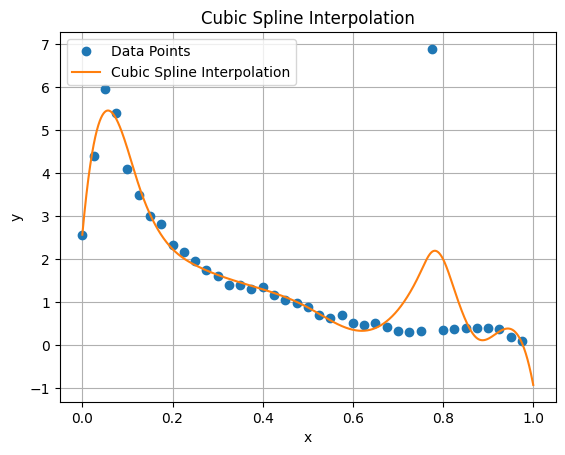

In [2]:
#using splines to model optimality as a function

import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

# Sample data points
x = np.array(xg_bins[0:40])
y = np.array(optimality)

# Create a cubic spline interpolation
cs = UnivariateSpline(x, y, k=3, s= 30)

# Generate new x values for plotting the interpolated curve
x_new = np.linspace(0, 1, 10000)
y_new = cs(x_new)

# Plotting
plt.plot(x, y, 'o', label='Data Points')
plt.plot(x_new, y_new, label='Cubic Spline Interpolation')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [3]:

import os
import json
json_files = [f for f in os.listdir("/Users/jackcolvin/downloads/json1") if f.endswith('.json')]
#looping through match events 
for i, filename in enumerate(json_files):
    file_path = os.path.join("/Users/jackcolvin/downloads/json1", filename)
    df1 = pd.read_json(file_path)
    #mask out na values
    mask = ~(df1['shot'].isna())
    #getting xg, coordinates, and whether shot is contested
    xg = df1['shot'][mask].apply(lambda x: x.get('statsbomb_xg'))
    coords = df1['location'][mask]
    coords = np.array(coords)
    coords = np.vstack(coords)
    play_pattern = df1['play_pattern'][mask].apply(lambda x: x.get('id'))
    pressure = df1['under_pressure'][mask]
    pressure = np.nan_to_num(pressure, nan=0)
    mask2 = play_pattern == 1
    xg = np.array(xg[mask2])
    pressure = np.array(pressure[mask2])
    play_pattern = np.array(play_pattern[mask2])
    coords = np.array(coords[mask2])
    x = coords[:,0]
    y = coords[:,1]
    #create an array to be used for training 
    array = np.array([x, y, pressure, xg])
    outcome = np.array(df1['shot'][mask][mask2].apply(lambda x: x.get('outcome')).apply(lambda x: x.get('name')).apply(lambda x: 1 if x == "Goal" else 0))
    if i == 0: 
        array1 = array
        outcome1 = outcome
    else: 
        array1 = np.hstack([array1, array])
        outcome1 = np.hstack([outcome1, outcome])
        #stack arrays from each match json file
        
        
print(array1)
print(len(outcome1))
print(pressure)



[[1.0830000e+02 1.0810000e+02 1.0050000e+02 ... 1.0320000e+02
  1.1470000e+02 9.7500000e+01]
 [4.7000000e+01 3.4300000e+01 5.7700000e+01 ... 2.7000000e+01
  3.7100000e+01 3.2700000e+01]
 [0.0000000e+00 1.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [1.6928093e-01 8.6954124e-02 2.9589606e-02 ... 3.6396902e-02
  5.6979080e-01 4.7250360e-02]]
28870
[0. 0. 0. 1. 0. 0. 0.]


In [4]:

mask = ~(df1['shot'].isna())
print(df1['shot'][mask])
print(df1['shot'][900])

320     {'statsbomb_xg': 0.016898135, 'end_location': ...
423     {'statsbomb_xg': 0.008396549, 'end_location': ...
680     {'statsbomb_xg': 0.007129788000000001, 'end_lo...
919     {'statsbomb_xg': 0.021201078, 'end_location': ...
1049    {'statsbomb_xg': 0.08172251, 'end_location': [...
1188    {'statsbomb_xg': 0.34130928, 'end_location': [...
1192    {'statsbomb_xg': 0.29814029999999997, 'end_loc...
1447    {'statsbomb_xg': 0.38354102, 'end_location': [...
1674    {'statsbomb_xg': 0.04288346, 'end_location': [...
1952    {'statsbomb_xg': 0.03005607, 'end_location': [...
1961    {'statsbomb_xg': 0.049093578000000006, 'end_lo...
2116    {'statsbomb_xg': 0.022309680000000002, 'end_lo...
2224    {'statsbomb_xg': 0.036396902, 'end_location': ...
2277    {'statsbomb_xg': 0.5697907999999999, 'end_loca...
2363    {'statsbomb_xg': 0.7835000000000001, 'end_loca...
2622    {'statsbomb_xg': 0.04725036, 'end_location': [...
2748    {'statsbomb_xg': 0.06913356500000001, 'end_loc...
2906    {'stat

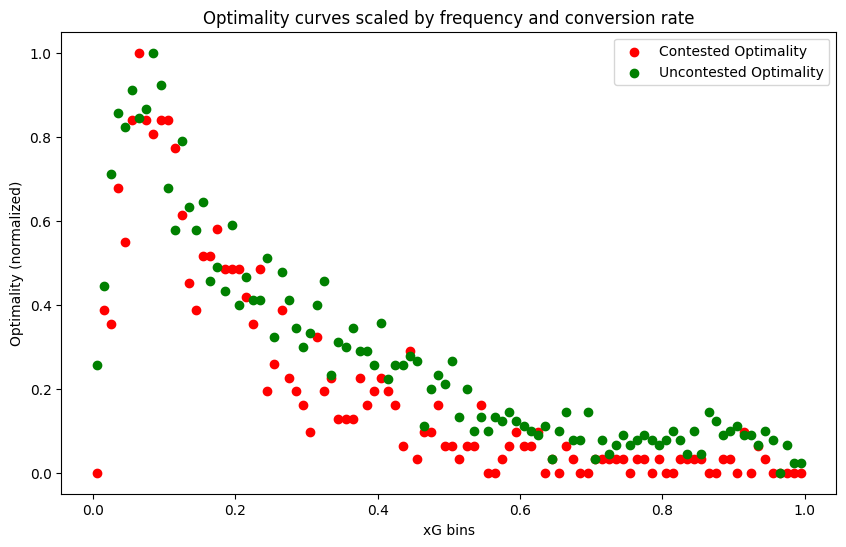

In [5]:
import numpy as np
import matplotlib.pyplot as plt


contested_flags = array1[2, :]        
xgtrain = array1[3, :]
ytrain = outcome1                     
#creating training and test array for both contested and uncontested optimality plots

num_bins = 100
bin_edges = np.linspace(0, 1, num_bins + 1)
bin_labels = (bin_edges[:-1] + bin_edges[1:]) / 2

# Bin shots by xG
bin_indices = np.digitize(xgtrain, bin_edges) - 1

total_shots = len(ytrain)

optimality_contested = np.zeros(num_bins)
optimality_uncontested = np.zeros(num_bins)

for i in range(num_bins):
    mask_bin = (bin_indices == i)

    num_in_bin = np.sum(mask_bin) 
    if num_in_bin == 0:
        continue

    # Contested shots in this bin
    contested_mask = mask_bin & (contested_flags == 1)
    num_contested = np.sum(contested_mask)
    if num_contested > 0:
        conversion_contested = np.mean(ytrain[contested_mask])
        freq_contested = num_contested / total_shots
        optimality_contested[i] = freq_contested * conversion_contested
    else:
        optimality_contested[i] = 0

    # Uncontested shots in this bin
    uncontested_mask = mask_bin & (contested_flags == 0)
    num_uncontested = np.sum(uncontested_mask)
    if num_uncontested > 0:
        conversion_uncontested = np.mean(ytrain[uncontested_mask])
        freq_uncontested = num_uncontested / total_shots
        optimality_uncontested[i] = freq_uncontested * conversion_uncontested
    else:
        optimality_uncontested[i] = 0

# Normalize so optimality for contested and uncontested can be compared in a useful way
if np.max(optimality_contested) > 0:
    optimality_contested /= np.max(optimality_contested)
if np.max(optimality_uncontested) > 0:
    optimality_uncontested /= np.max(optimality_uncontested)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(bin_labels, optimality_contested, label='Contested Optimality', color='red')
plt.scatter(bin_labels, optimality_uncontested, label='Uncontested Optimality', color='green')
plt.xlabel("xG bins")
plt.ylabel("Optimality (normalized)")
plt.title("Optimality curves scaled by frequency and conversion rate")
plt.legend()
plt.show()

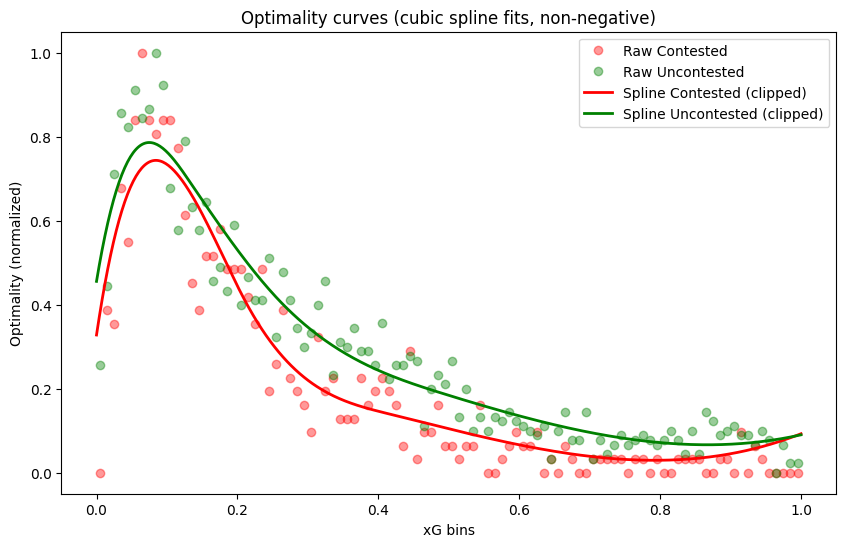

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# Filter out bins where optimality is zero, as they likely have no useful data
mask_contested = optimality_contested > 0
mask_uncontested = optimality_uncontested > 0

# Fit cubic splines
spline_contested = UnivariateSpline(bin_labels[mask_contested], 
                                    optimality_contested[mask_contested],
                                    k=3, s= .5)
spline_uncontested = UnivariateSpline(bin_labels[mask_uncontested], 
                                      optimality_uncontested[mask_uncontested],
                                      k=3, s=.5)


x_smooth = np.linspace(0, 1, 500)

# clipping to avoid negative values (as optimality only makes sense on a 0,1 scale)
optimality_contested_smooth = np.clip(spline_contested(x_smooth), 0, None)
optimality_uncontested_smooth = np.clip(spline_uncontested(x_smooth), 0, None)

# Plot
plt.figure(figsize=(10,6))
plt.plot(bin_labels, optimality_contested, 'o', color='red', alpha=0.4, label='Raw Contested')
plt.plot(bin_labels, optimality_uncontested, 'o', color='green', alpha=0.4, label='Raw Uncontested')

plt.plot(x_smooth, optimality_contested_smooth, color='red', linewidth=2, label='Spline Contested (clipped)')
plt.plot(x_smooth, optimality_uncontested_smooth, color='green', linewidth=2, label='Spline Uncontested (clipped)')

plt.xlabel("xG bins")
plt.ylabel("Optimality (normalized)")
plt.title("Optimality curves (cubic spline fits, non-negative)")
plt.legend()
plt.show()

In [37]:
mask = array1[2,:] == 0
#mask out values that are 0

xg_ncont = array1[3,:][mask]
nc = array1[2,:][mask]
ncy = array1[1,:][mask]
ncx = array1[0,:][mask]

#create training dataset
xtrain1 = np.vstack([ncx, ncy, nc])
print(xtrain1)

xg_cont = array1[3,:][~mask]
c = array1[2,:][~mask]
cy = array1[1,:][~mask]
cx = array1[0,:][~mask]

xtrain2 = np.vstack([cx, cy, c])
print(xtrain2)

#create y training set
ytrain_new_nc = np.interp(xg_ncont, x_smooth, optimality_uncontested_smooth)
ytrain_new = np.interp(xg_cont, x_smooth, optimality_contested_smooth)


from scipy.interpolate import RBFInterpolator
xtrain = np.hstack([xtrain1, xtrain2])
ytrain = np.hstack([ytrain_new_nc, ytrain_new])
ytrain_2 = ytrain/np.max(ytrain)

#use rbf interpolation to interpolate xg -> optimality function over all of field space
master_func1 = RBFInterpolator(xtrain.T, ytrain_2.T, kernel='cubic', neighbors=200, smoothing = 1, degree = 0)

[[108.3 100.5  96.5 ... 103.2 114.7  97.5]
 [ 47.   57.7  39.7 ...  27.   37.1  32.7]
 [  0.    0.    0.  ...   0.    0.    0. ]]
[[108.1 110.8 109.7 ... 100.3 106.2 112.7]
 [ 34.3  43.2  49.7 ...  55.   51.6  52. ]
 [  1.    1.    1.  ...   1.    1.    1. ]]


/var/folders/m0/hlc6y73128n1wbz2yg_t5bh40000gn/T/ipykernel_1190/1027441156.py:27: UserWarning: `degree` should not be below 1 except -1 when `kernel` is 'cubic'.The interpolant may not be uniquely solvable, and the smoothing parameter may have an unintuitive effect.
  master_func1 = RBFInterpolator(xtrain.T, ytrain_2.T, kernel='cubic', neighbors=200, smoothing = 1, degree = 0)


In [38]:
predicted_optimality = master_func1([[110.1, 40, 0]])
print(predicted_optimality)

[0.64770539]


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_pitch(ax, x_min=85, x_max=120, y_min=10, y_max=70):
    # Draw the penalty box
    penalty_box = patches.Rectangle(
        (102, (80 - 44) / 2), 18, 44,
        linewidth=3, edgecolor='black', facecolor='none'
    )
    ax.add_patch(penalty_box)

    # Draw the  6-yard box
    six_yard_box = patches.Rectangle(
        (114, (80 - 20) / 2), 6, 20,
        linewidth=3, edgecolor='black', facecolor='none'
    )
    ax.add_patch(six_yard_box)

    # the Draw goal line
    ax.plot([120, 120], [(80 - 8) / 2, (80 + 8) / 2], color='black', linewidth=5)

    # Draw the outer penalty area rectangle to show context
    ax.plot([102, 120, 120, 102, 102], [18, 18, 62, 62, 18], color='black', linewidth=3)


    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.axis('off')

def plot_optimality_heatmap(master_func, fixed_features=None, feature_names=None):
    #region around goal to plot
    x_vals = np.linspace(85, 120, 120)
    y_vals = np.linspace(10, 70, 100)
    X, Y = np.meshgrid(x_vals, y_vals)


    n_features = master_func.n_features_in_ if hasattr(master_func, 'n_features_in_') else None
    if n_features is None:
        if fixed_features is not None:
            n_features = len(fixed_features)
        else:
            raise ValueError("Cannot determine number of features expected by master_func. Please provide fixed_features.")

    grid_points = np.zeros((X.size, n_features))

    # Assign x and y
    grid_points[:, 0] = X.ravel()
    grid_points[:, 1] = Y.ravel()


    if fixed_features is not None:
        for i, val in enumerate(fixed_features):
            if i >= 2:
                grid_points[:, i] = val
    else:
        if n_features > 2:
            grid_points[:, 2:] = 0

    #clipping optimality to [0, 1]
    optimality_grid = master_func(grid_points).reshape(X.shape)
    optimality_grid = np.clip(optimality_grid, 0, 1)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    draw_pitch(ax, x_min=85, x_max=120, y_min=10, y_max=70)

    heatmap = ax.contourf(X, Y, optimality_grid, levels=30, cmap='viridis', alpha=0.8)
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Predicted Optimality')

    ax.set_title('Optimality Heatmap (Wider Region Near Goal)')
    plt.show()

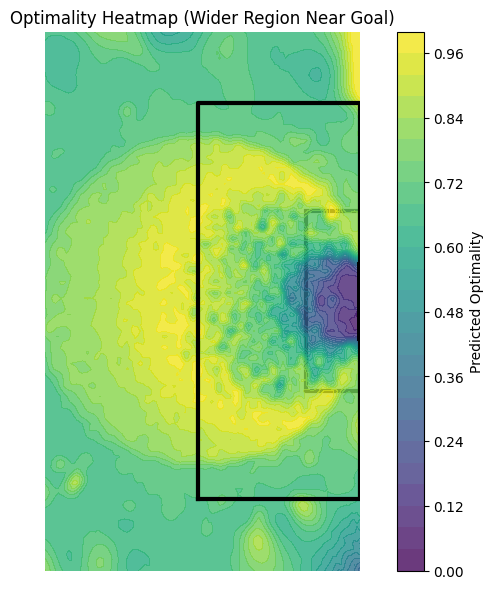

In [40]:
plot_optimality_heatmap(master_func1, fixed_features=[0, 0, 0])

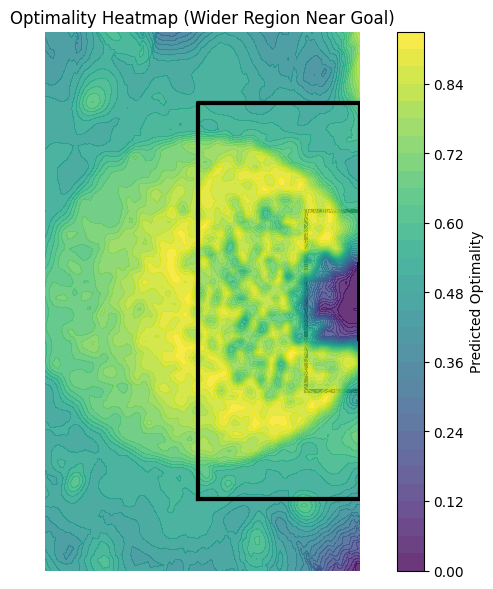

In [41]:
plot_optimality_heatmap(master_func1, fixed_features=[0, 0, 1])

In [42]:
def plot_optimality_difference_by_features(master_func, fixed_features1, fixed_features2):
    x_vals = np.linspace(85, 120, 120)
    y_vals = np.linspace(10, 70, 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    # Determine number of features
    n_features = master_func.n_features_in_ if hasattr(master_func, 'n_features_in_') else len(fixed_features1)
    
    grid_points = np.zeros((X.size, n_features))
    grid_points[:, 0] = X.ravel()
    grid_points[:, 1] = Y.ravel()

    # Heatmap 1
    grid_points1 = grid_points.copy()
    if len(fixed_features1) != n_features:
        raise ValueError("fixed_features1 length doesn't match model input")
    for i, val in enumerate(fixed_features1):
        if i >= 2:
            grid_points1[:, i] = val
    optimality_grid1 = np.clip(master_func(grid_points1), 0, 1).reshape(X.shape)

    # Heatmap 2
    grid_points2 = grid_points.copy()
    if len(fixed_features2) != n_features:
        raise ValueError("fixed_features2 length doesn't match model input")
    for i, val in enumerate(fixed_features2):
        if i >= 2:
            grid_points2[:, i] = val
    optimality_grid2 = np.clip(master_func(grid_points2), 0, 1).reshape(X.shape)

    # Difference
    diff_grid = optimality_grid1 - optimality_grid2

    
    max_abs = np.max(np.abs(diff_grid))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    draw_pitch(ax, x_min=85, x_max=120, y_min=10, y_max=70)


    heatmap = ax.contourf(
        X, Y, diff_grid, levels=30,
        cmap='seismic', alpha=0.8,
        vmin=-max_abs, vmax=+max_abs
    )
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Optimality Difference (First - Second)')

    ax.set_title('Difference Heatmap: Effect of Changing Fixed Features')
    plt.show()

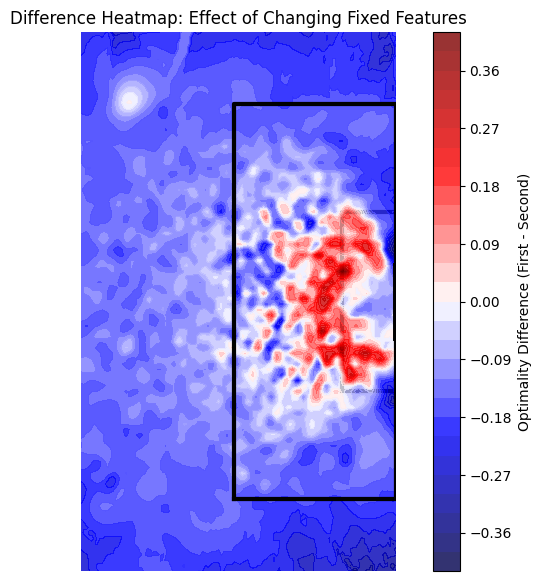

In [43]:
plot_optimality_difference_by_features(
    master_func1,
    fixed_features1=[0,0,1],
    fixed_features2=[0,0,0]
)

In [44]:
n_open = 1000
n_contested = 1000

# Generate uncontested shots outside the box 
x_open = np.random.uniform(85, 100, n_open)
y_open = np.random.uniform(18, 62, n_open)  
contested_flag_open = np.zeros(n_open)  

# Generate contested shots inside box but outside 6-yard box:
x_cont = np.random.uniform(102, 114, n_contested)
y_cont = np.random.uniform(22, 58, n_contested)
contested_flag_cont = np.ones(n_contested)  # contested


X_open = np.vstack([x_open, y_open, contested_flag_open]).T
X_cont = np.vstack([x_cont, y_cont, contested_flag_cont]).T

# Predict optimality
optimality_open = master_func1(X_open)
optimality_cont = master_func1(X_cont)


print(f"Average predicted optimality for uncontested shots outside box: {np.mean(optimality_open):.3f}")
print(f"Average predicted optimality for contested shots inside box (but outside 6-yard box): {np.mean(optimality_cont):.3f}")

Average predicted optimality for uncontested shots outside box: 0.796
Average predicted optimality for contested shots inside box (but outside 6-yard box): 0.776


0       {'id': 226, 'name': 'Hellas Verona'}
1       {'id': 226, 'name': 'Hellas Verona'}
2       {'id': 226, 'name': 'Hellas Verona'}
3       {'id': 226, 'name': 'Hellas Verona'}
4               {'id': 236, 'name': 'Lazio'}
                        ...                 
3287    {'id': 226, 'name': 'Hellas Verona'}
3288    {'id': 226, 'name': 'Hellas Verona'}
3289    {'id': 226, 'name': 'Hellas Verona'}
3290    {'id': 226, 'name': 'Hellas Verona'}
3291    {'id': 226, 'name': 'Hellas Verona'}
Name: possession_team, Length: 3292, dtype: object


In [74]:
for i, filename in enumerate(json_files):
    file_path = os.path.join("/Users/jackcolvin/downloads/json1", filename)
    df1 = pd.read_json(file_path)
    mask = ~(df1['shot'].isna())
    xg = df1['shot'][mask].apply(lambda x: x.get('statsbomb_xg'))
    coords = df1['location'][mask]
    coords = np.array(coords)
    coords = np.vstack(coords)
    play_pattern = df1['play_pattern'][mask].apply(lambda x: x.get('id'))
    pressure = df1['under_pressure'][mask]
    pressure = np.nan_to_num(pressure, nan=0)
    mask2 = play_pattern == 1
    pressure = np.array(pressure[mask2])
    play_pattern = np.array(play_pattern[mask2])
    coords = np.array(coords[mask2])
    x = coords[:,0]
    y = coords[:,1]
    outcome = np.array(df1['shot'][mask][mask2].apply(lambda x: x.get('outcome')).apply(lambda x: x.get('name')).apply(lambda x: 1 if x == "Goal" else 0))
    mask3 = df1['possession_team'].apply(lambda x: x.get('name') == 'Liverpool').to_numpy()
    mask3 = mask3[mask][mask2]
    x = x[mask3]
    y = y[mask3]
    outcome = outcome[mask3]
    pressure = pressure[mask3]
    array = np.array([x, y, pressure])
    if i == 0: 
        array1 = array
        outcome1 = outcome
    else: 
        array1 = np.hstack([array1, array])
        outcome1 = np.hstack([outcome1, outcome])
        

In [75]:
Liverpool_optimalities = master_func1(array1.T)
print(np.mean(Liverpool_optimalities))

0.8269581151172297


In [76]:
for i, filename in enumerate(json_files):
    file_path = os.path.join("/Users/jackcolvin/downloads/json1", filename)
    df1 = pd.read_json(file_path)
    mask = ~(df1['shot'].isna())
    xg = df1['shot'][mask].apply(lambda x: x.get('statsbomb_xg'))
    coords = df1['location'][mask]
    coords = np.array(coords)
    coords = np.vstack(coords)
    play_pattern = df1['play_pattern'][mask].apply(lambda x: x.get('id'))
    pressure = df1['under_pressure'][mask]
    pressure = np.nan_to_num(pressure, nan=0)
    mask2 = play_pattern == 1
    pressure = np.array(pressure[mask2])
    play_pattern = np.array(play_pattern[mask2])
    coords = np.array(coords[mask2])
    x = coords[:,0]
    y = coords[:,1]
    outcome = np.array(df1['shot'][mask][mask2].apply(lambda x: x.get('outcome')).apply(lambda x: x.get('name')).apply(lambda x: 1 if x == "Goal" else 0))
    mask3 = (df1['possession_team'].apply(lambda x: x.get('name')) == 'Everton').to_numpy()
    mask3 = mask3[mask][mask2]
    x = x[mask3]
    y = y[mask3]
    outcome = outcome[mask3]
    pressure = pressure[mask3]
    array = np.array([x, y, pressure])
    if i == 0: 
        array1 = array
        outcome1 = outcome
    else: 
        array1 = np.hstack([array1, array])
        outcome1 = np.hstack([outcome1, outcome])

In [77]:
Everton_optimalities = master_func1(array1.T)
print(np.mean(Everton_optimalities))

0.814731819631861
3


In [78]:
for i, filename in enumerate(json_files):
    file_path = os.path.join("/Users/jackcolvin/downloads/json1", filename)
    df1 = pd.read_json(file_path)
    mask = ~(df1['shot'].isna())
    xg = df1['shot'][mask].apply(lambda x: x.get('statsbomb_xg'))
    coords = df1['location'][mask]
    coords = np.array(coords)
    coords = np.vstack(coords)
    play_pattern = df1['play_pattern'][mask].apply(lambda x: x.get('id'))
    pressure = df1['under_pressure'][mask]
    pressure = np.nan_to_num(pressure, nan=0)
    mask2 = play_pattern == 1
    pressure = np.array(pressure[mask2])
    play_pattern = np.array(play_pattern[mask2])
    coords = np.array(coords[mask2])
    x = coords[:,0]
    y = coords[:,1]
    outcome = np.array(df1['shot'][mask][mask2].apply(lambda x: x.get('outcome')).apply(lambda x: x.get('name')).apply(lambda x: 1 if x == "Goal" else 0))
    mask3 = (df1['possession_team'].apply(lambda x: x.get('name')) == 'Crystal Palace').to_numpy()
    mask3 = mask3[mask][mask2]
    x = x[mask3]
    y = y[mask3]
    outcome = outcome[mask3]
    pressure = pressure[mask3]
    array = np.array([x, y, pressure])
    if i == 0: 
        array1 = array
        outcome1 = outcome
    else: 
        array1 = np.hstack([array1, array])
        outcome1 = np.hstack([outcome1, outcome])

In [79]:
Palace_optimalities = master_func1(array1.T)
print(np.mean(Palace_optimalities))

0.8040836107855726


In [13]:
import os
import json
json_files = [f for f in os.listdir("/Users/jackcolvin/downloads/json1") if f.endswith('.json')]

for i, filename in enumerate(json_files):
    file_path = os.path.join("/Users/jackcolvin/downloads/json1", filename)
    df1 = pd.read_json(file_path)
    mask = ~(df1['shot'].isna())
    xg = df1['shot'][mask].apply(lambda x: x.get('statsbomb_xg'))
    coords = df1['location'][mask]
    coords = np.array(coords)
    coords = np.vstack(coords)
    play_pattern = df1['play_pattern'][mask].apply(lambda x: x.get('id'))
    pressure = df1['under_pressure'][mask]
    pressure = np.nan_to_num(pressure, nan=0)
    mask2 = play_pattern == 1
    pressure = np.array(pressure[mask2])
    play_pattern = np.array(play_pattern[mask2])
    coords = np.array(coords[mask2])
    xg = np.array(xg[mask2])
    x = coords[:,0]
    y = coords[:,1]
    outcome = np.array(df1['shot'][mask][mask2].apply(lambda x: x.get('outcome')).apply(lambda x: x.get('name')).apply(lambda x: 1 if x == "Goal" else 0))
    mask3 = df1['possession_team'].apply(lambda x: x.get('name') == 'Liverpool').to_numpy()
    mask3 = mask3[mask][mask2]
    x = x[mask3]
    y = y[mask3]
    xg = xg[mask3]
    outcome = outcome[mask3]
    pressure = pressure[mask3]
    array = np.array([x, y, pressure])
    if i == 0: 
        array1 = array
        outcome1 = outcome
        xgtrain = xg
    else: 
        array1 = np.hstack([array1, array])
        xgtrain = np.hstack([xgtrain, xg])
        outcome1 = np.hstack([outcome1, outcome])

In [14]:
print(array1)

[[102.7 101.  103.5 105.8 106.4 103.6 106.1 107.4  99.2 101.7 114.2  99.7
   92.5 103.8 111.6 103.5  90.2 111.8  94.9  92.4 108.2 113.8 108.7  91.
   93.8  92.8 109.4 110.5 106.5 100.3  91.   95.7  91.7 110.4  94.  107.4
  104.2 110.7 101.5  88.2 106.   99.2  95.7 102.5 110.  105.5 110.1 109.
   98.6 104.3  98.9 114.3 114.3 115.8 103.3  98.7 104.8 101.5 111.3 107.8
   91.7  96.7 101.7 105.6 115.8  94.6  98.6  94.2  96.6 102.8  99.3  96.3
   92.   98.4  89.   96.  105.9 103.8 106.5  94.8  93.6  97.2 106.4 103.8
   93.9  94.6 103.3 112.1 105.7 106.4  92.1  98.7  92.8 112.  105.  100.4
  107.8  91.5  94.   95.6  98.8  90.2  93.4 107.8  93.5 102.3  86.6 100.
  105.   94.6 102.8  93.4  95.9 109.   99.2  94.4 101.7 111.5 109.5 106.2
  110.   95.7  97.9 104.2  90.8  98.3 102.6 101.9  95.1  97.8  94.1  97.
  104.9  97.6 100.1 105.4  96.8  86.2  95.9  84.7 107.3 108.  108.5 102.1
  109.6 113.9 107.7 108.5  98.3  97.5  98.4 109.   86.4 104.8  94.8  92.7
  108.6 103.9 103.1  95.5  90.6  98.4  57.

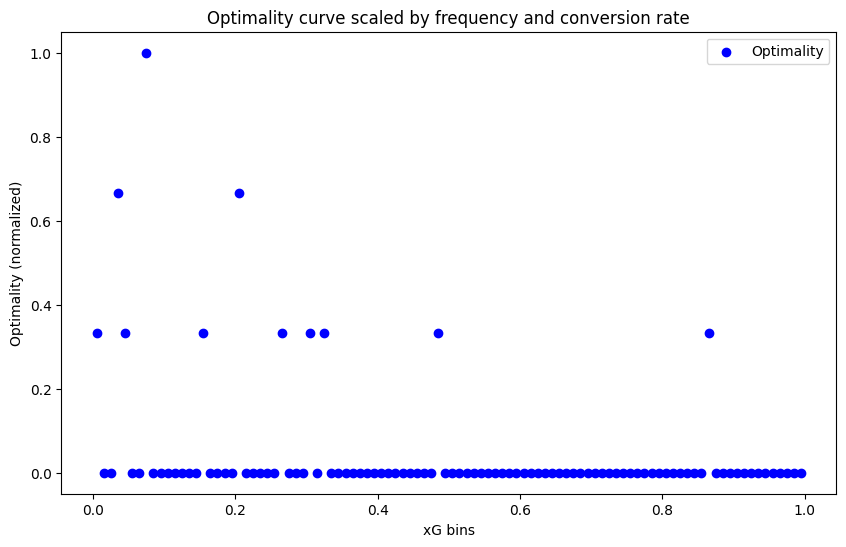

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Your data
# contested_flags = array1[2, :]        # no longer needed
ytrain = outcome1                      # shot outcomes, e.g., 0/1 for conversion

num_bins = 100
bin_edges = np.linspace(0, 1, num_bins + 1)
bin_labels = (bin_edges[:-1] + bin_edges[1:]) / 2

# Bin shots by xG
bin_indices = np.digitize(xgtrain, bin_edges) - 1

total_shots = len(ytrain)
optimality = np.zeros(num_bins)

for i in range(num_bins):
    mask_bin = (bin_indices == i)
    num_in_bin = np.sum(mask_bin)

    if num_in_bin == 0:
        continue  # skip empty bins

    conversion_rate = np.mean(ytrain[mask_bin])
    freq = num_in_bin / total_shots
    optimality[i] = freq * conversion_rate

# Optional: normalize so max=1 for visualization
if np.max(optimality) > 0:
    optimality /= np.max(optimality)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(bin_labels, optimality, color='blue', label='Optimality')
plt.xlabel("xG bins")
plt.ylabel("Optimality (normalized)")
plt.title("Optimality curve scaled by frequency and conversion rate")
plt.legend()
plt.show()